In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from sklearn.cluster import DBSCAN
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [2]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".csv") or f.endswith(".jpg"):
            print(os.path.join(root, f))
            break

/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv
/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/styles.csv
/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/images/31973.jpg
/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images/31973.jpg


In [3]:
BASE_PATH = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small"
STYLES_CSV = f"{BASE_PATH}/myntradataset/styles.csv"
IMAGES_DIR = f"{BASE_PATH}/myntradataset/images"

df = pd.read_csv(STYLES_CSV, on_bad_lines="skip")
df["image_path"] = df["id"].apply(lambda x: f"{IMAGES_DIR}/{x}.jpg")
df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)

print(f"✅ Dataset loaded: {len(df)} products")
print(df[["id","articleType","baseColour","productDisplayName"]].head())

✅ Dataset loaded: 44419 products
      id  articleType baseColour  \
0  15970       Shirts  Navy Blue   
1  39386        Jeans       Blue   
2  59263      Watches     Silver   
3  21379  Track Pants      Black   
4  53759      Tshirts       Grey   

                              productDisplayName  
0               Turtle Check Men Navy Blue Shirt  
1             Peter England Men Party Blue Jeans  
2                       Titan Women Silver Watch  
3  Manchester United Men Solid Black Track Pants  
4                          Puma Men Grey T-shirt  


In [4]:
import os

# Check if CLIP is already cached on this Kaggle environment
cache_paths = [
    "/root/.cache/huggingface",
    "/usr/local/lib/python3.10",
    "/kaggle/working"
]

for path in cache_paths:
    if os.path.exists(path):
        for root, dirs, files in os.walk(path):
            for f in files:
                if "clip" in f.lower():
                    print(os.path.join(root, f))

In [5]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()
print("✅ CLIP loaded!")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ CLIP loaded!


In [45]:
def get_image_embedding(image_path):
    try:
        image = Image.open(image_path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt")
        with torch.no_grad():
            output = model.vision_model(**inputs)
            emb = model.visual_projection(output.pooler_output)
        emb = emb.detach().numpy().flatten()
        emb = emb / np.linalg.norm(emb)
        return emb
    except Exception as e:
        print(f"Error: {e}")
        return None

# Test single image first
test = get_image_embedding(sample_df.iloc[0]['image_path'])
if test is not None:
    print(f"✅ Shape: {test.shape}")
else:
    print("❌ Failed")

✅ Shape: (512,)


In [49]:
sample_df = df.head(500).copy()
embeddings = []
valid_indices = []

for i, row in sample_df.iterrows():
    emb = get_image_embedding(row["image_path"])
    if emb is not None:
        embeddings.append(emb)
        valid_indices.append(i)
    if len(embeddings) % 100 == 0 and len(embeddings) > 0:
        print(f"Processed {len(embeddings)} images...")

embeddings = np.array(embeddings).astype("float32")
valid_df = sample_df.loc[valid_indices].reset_index(drop=True)
print(f"✅ Done! Shape: {embeddings.shape}")

Processed 100 images...
Processed 200 images...
Processed 300 images...
Processed 400 images...
Processed 500 images...
✅ Done! Shape: (500, 512)


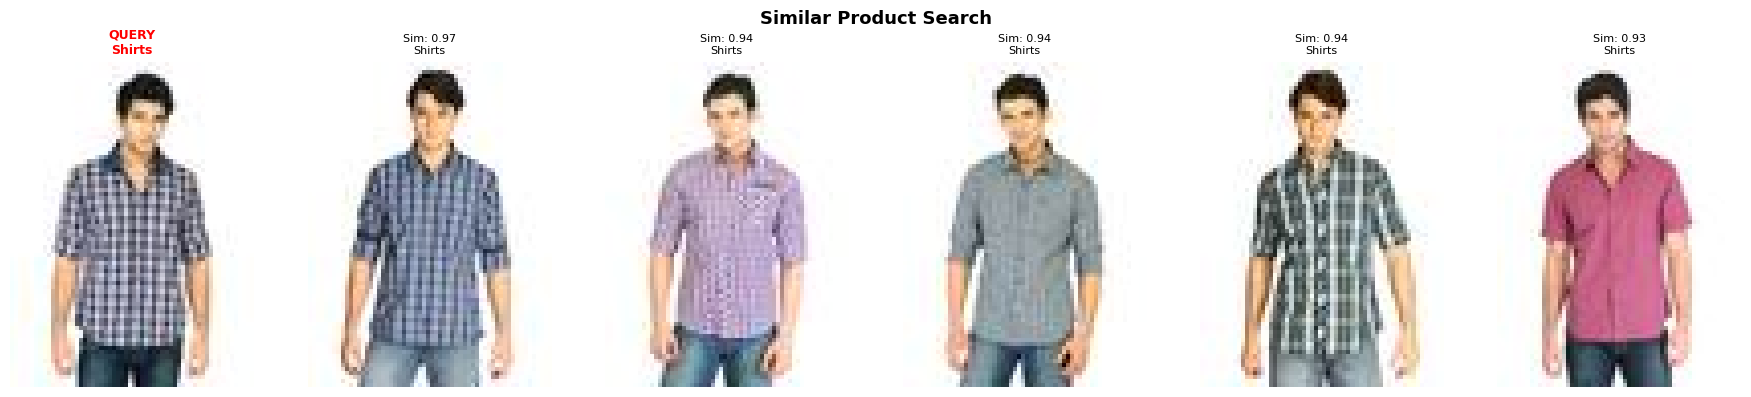

✅ Similarity search working!


In [58]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def search_similar(query_idx, top_k=5):
    query_emb = embeddings[query_idx]
    similarities = np.array([
        cosine_similarity(query_emb, embeddings[i]) 
        for i in range(len(embeddings))
    ])
    top_indices = np.argsort(similarities)[::-1][1:top_k+1]
    top_scores = similarities[top_indices]
    return list(zip(top_indices, top_scores))

def show_similar(query_idx, top_k=5):
    results = search_similar(query_idx, top_k)
    query_row = valid_df.iloc[query_idx]
    fig, axes = plt.subplots(1, top_k+1, figsize=(18, 4))
    axes[0].imshow(Image.open(query_row["image_path"]))
    axes[0].set_title(f"QUERY\n{query_row['articleType']}", 
                       fontsize=9, color="red", fontweight="bold")
    axes[0].axis("off")
    for j, (idx, score) in enumerate(results):
        row = valid_df.iloc[idx]
        axes[j+1].imshow(Image.open(row["image_path"]))
        axes[j+1].set_title(f"Sim: {score:.2f}\n{row['articleType']}", fontsize=8)
        axes[j+1].axis("off")
    plt.suptitle("Similar Product Search", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_similar(0)
print("✅ Similarity search working!")

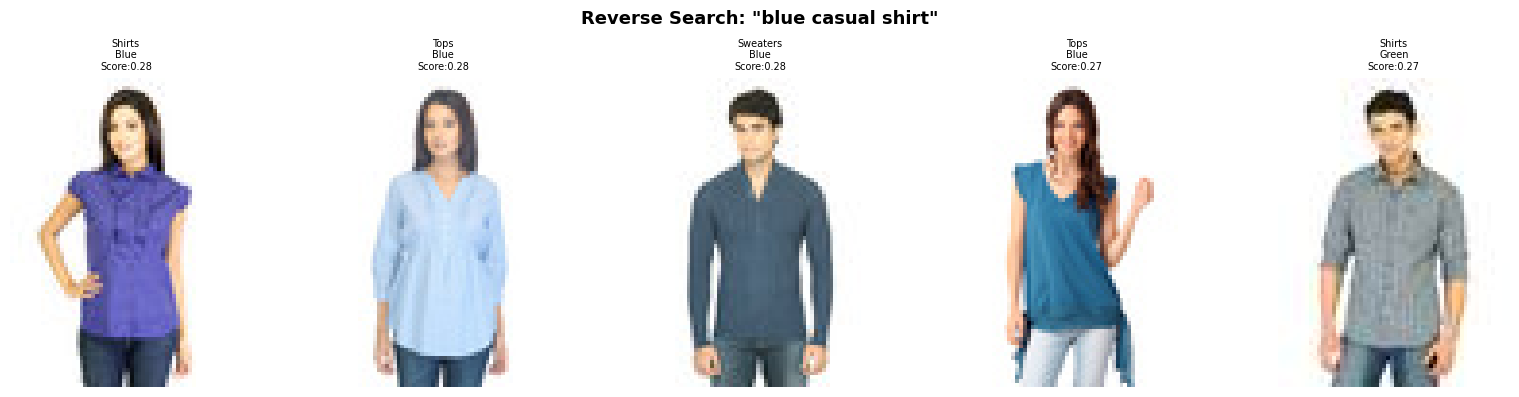

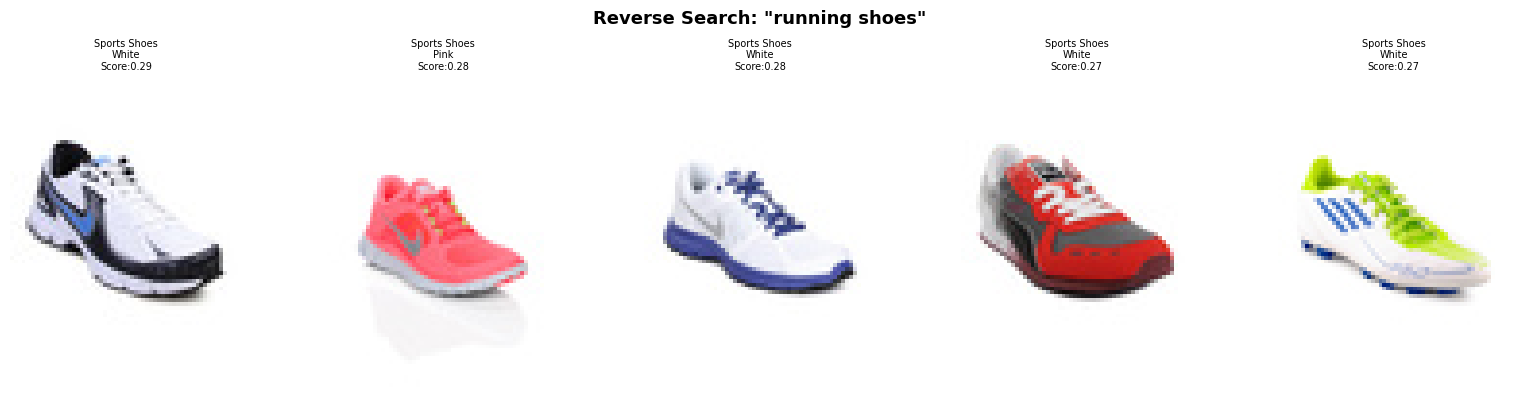

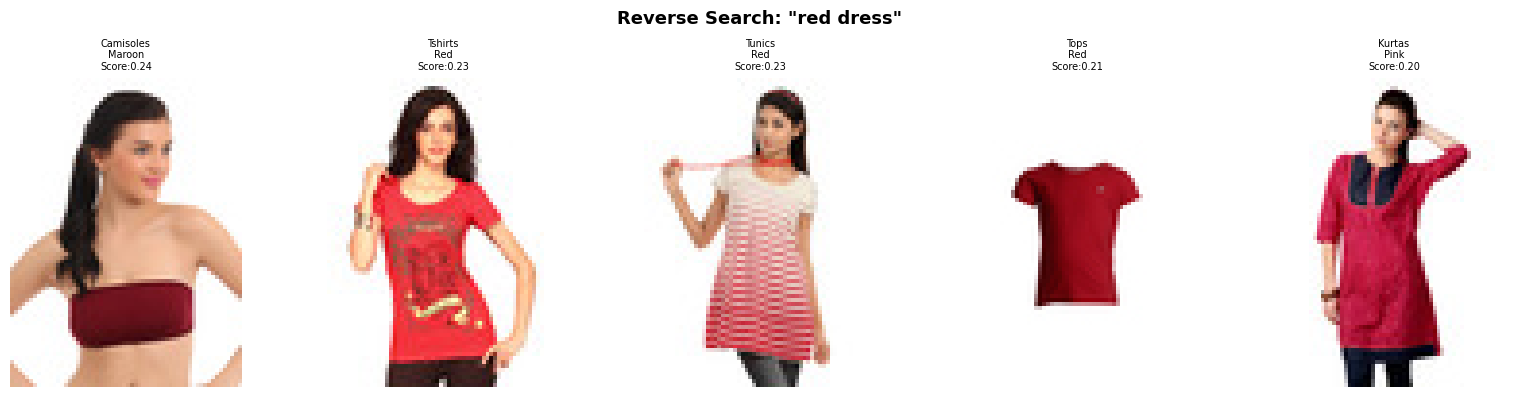

✅ Reverse search working!


In [59]:
def get_text_embedding(query_text):
    inputs = processor(text=[query_text], return_tensors="pt", padding=True)
    with torch.no_grad():
        output = model.text_model(**inputs)
        emb = model.text_projection(output.pooler_output)
    emb = emb.detach().numpy().flatten()
    emb = emb / np.linalg.norm(emb)
    return emb

def text_search(query_text, top_k=5):
    text_emb = get_text_embedding(query_text)
    similarities = np.array([
        cosine_similarity(text_emb, embeddings[i])
        for i in range(len(embeddings))
    ])
    top_indices = np.argsort(similarities)[::-1][:top_k]
    top_scores = similarities[top_indices]

    fig, axes = plt.subplots(1, top_k, figsize=(16, 4))
    for j, idx in enumerate(top_indices):
        row = valid_df.iloc[idx]
        axes[j].imshow(Image.open(row["image_path"]))
        axes[j].set_title(f"{row['articleType']}\n{row['baseColour']}\nScore:{top_scores[j]:.2f}", fontsize=7)
        axes[j].axis("off")
    plt.suptitle(f'Reverse Search: "{query_text}"', fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

text_search("blue casual shirt")
text_search("running shoes")
text_search("red dress")
print("✅ Reverse search working!")

✅ Duplicate groups found: 16
✅ Unique standalone products: 68
✅ Total unique catalog size: 84


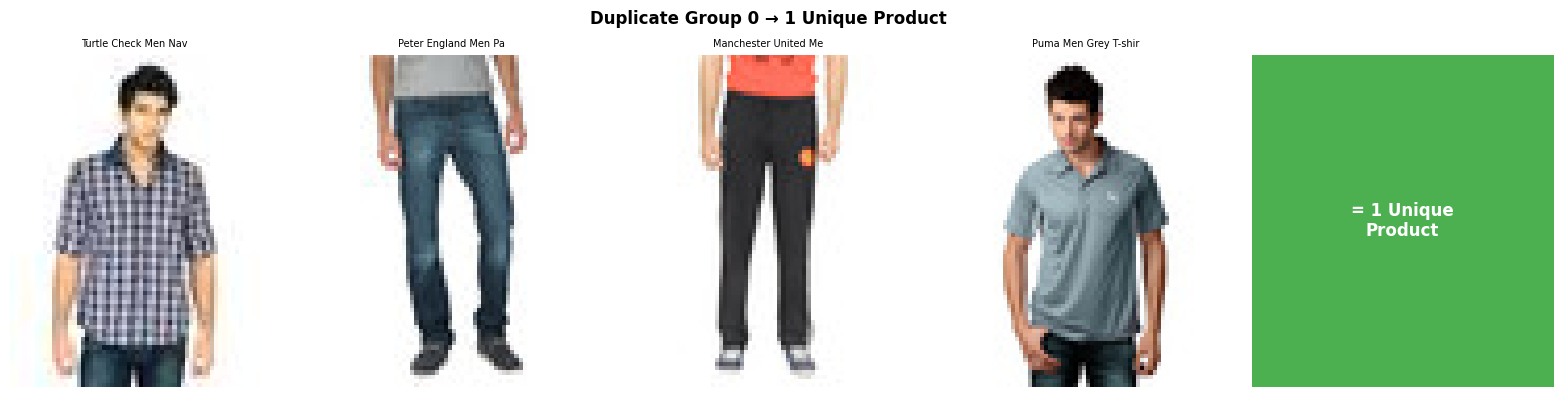

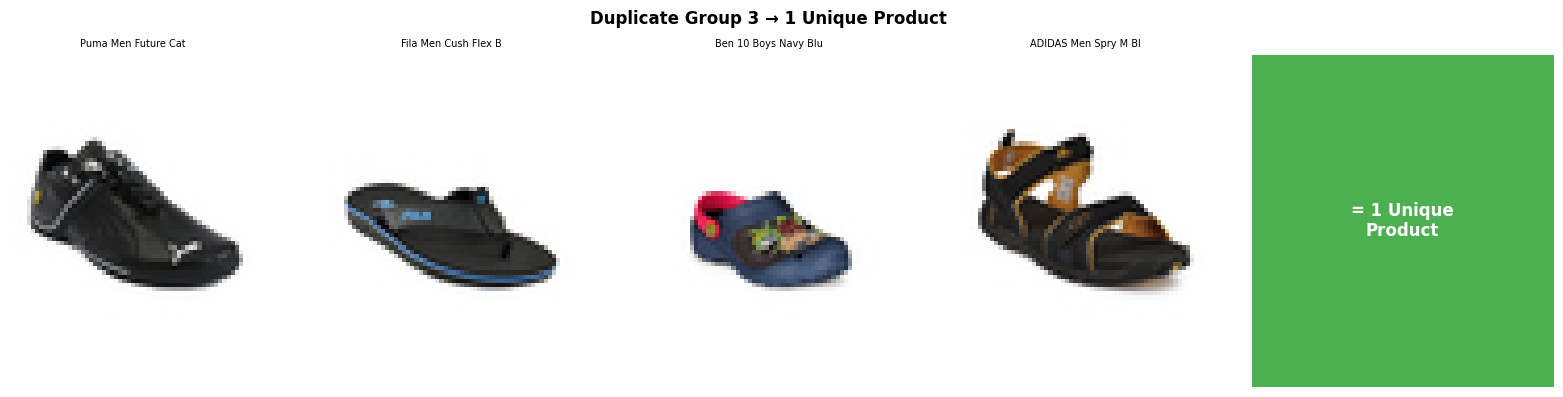

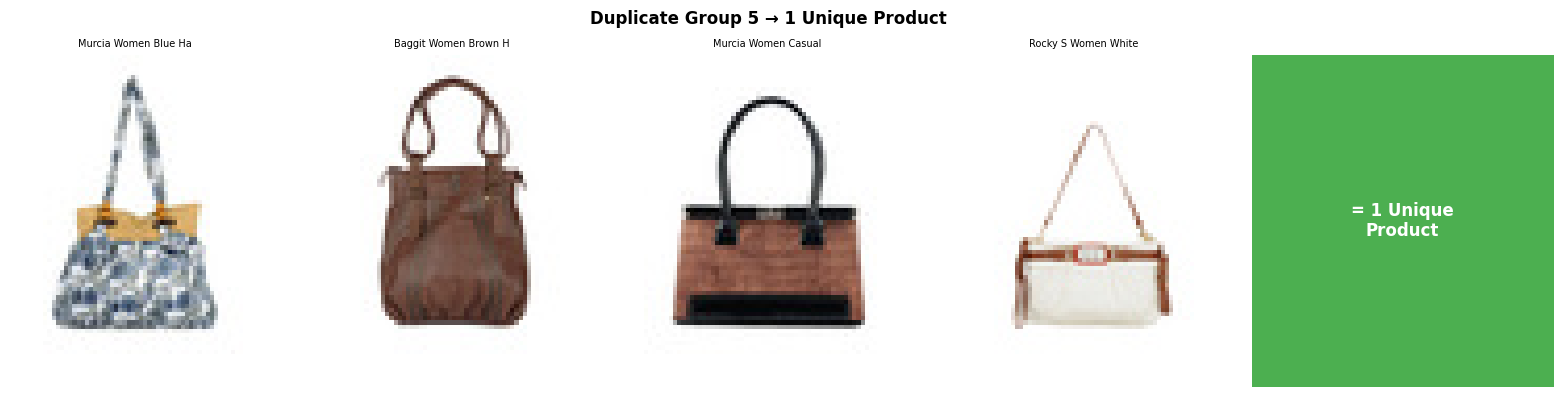

✅ Duplicate detection working!


In [61]:
clustering = DBSCAN(eps=0.12, min_samples=2, metric="cosine", n_jobs=-1)
labels = clustering.fit_predict(embeddings)

valid_df["cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print(f"✅ Duplicate groups found: {n_clusters}")
print(f"✅ Unique standalone products: {n_noise}")
print(f"✅ Total unique catalog size: {n_clusters + n_noise}")

def show_duplicate_group(cluster_id):
    group = valid_df[valid_df["cluster"] == cluster_id].head(4)
    n = len(group)
    fig, axes = plt.subplots(1, n+1, figsize=(16, 4))
    for j, (_, row) in enumerate(group.iterrows()):
        axes[j].imshow(Image.open(row["image_path"]))
        axes[j].set_title(f"{row['productDisplayName'][:20]}", fontsize=7)
        axes[j].axis("off")
    axes[n].add_patch(plt.Rectangle((0,0), 1, 1,
                      color="#4CAF50", transform=axes[n].transAxes))
    axes[n].text(0.5, 0.5, "= 1 Unique\nProduct", ha="center", va="center",
                 fontsize=12, fontweight="bold", color="white",
                 transform=axes[n].transAxes)
    axes[n].set_xlim(0,1)
    axes[n].set_ylim(0,1)
    axes[n].axis("off")
    plt.suptitle(f"Duplicate Group {cluster_id} → 1 Unique Product",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

valid_clusters = valid_df[valid_df["cluster"] != -1]["cluster"].value_counts()
for cluster_id in valid_clusters.index[:3]:
    show_duplicate_group(cluster_id)

print("✅ Duplicate detection working!")

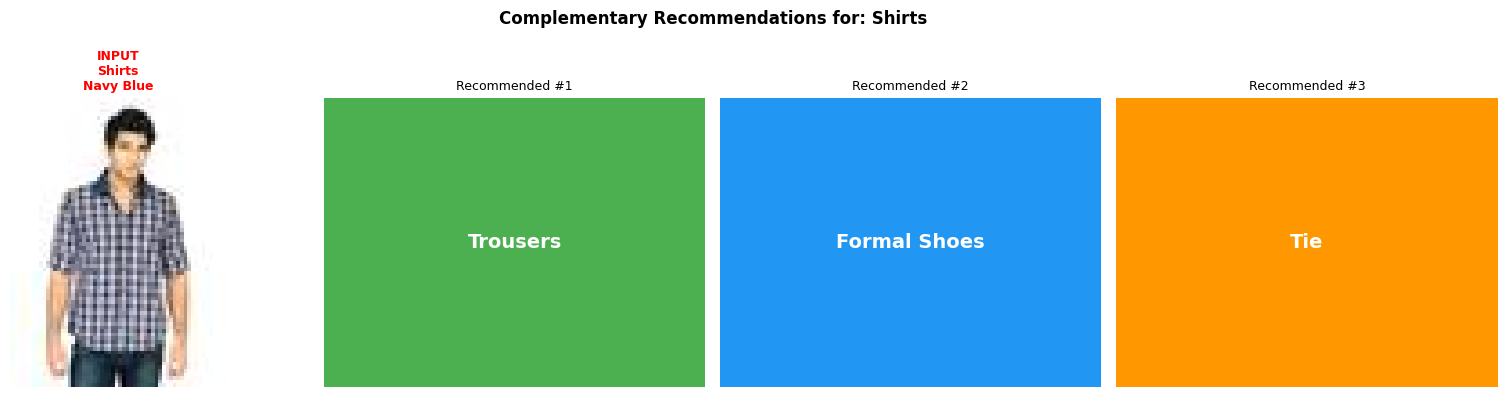

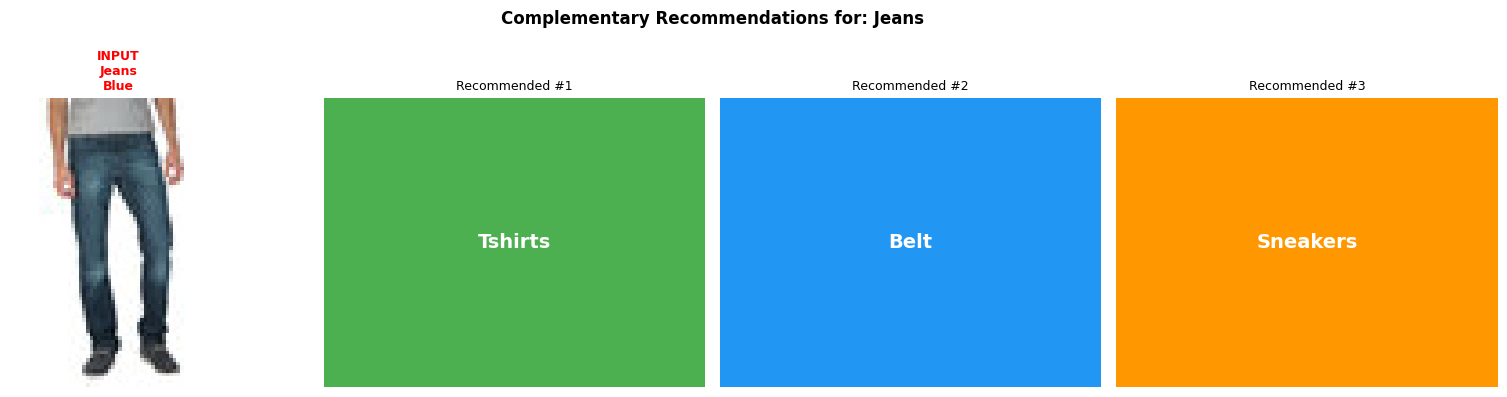

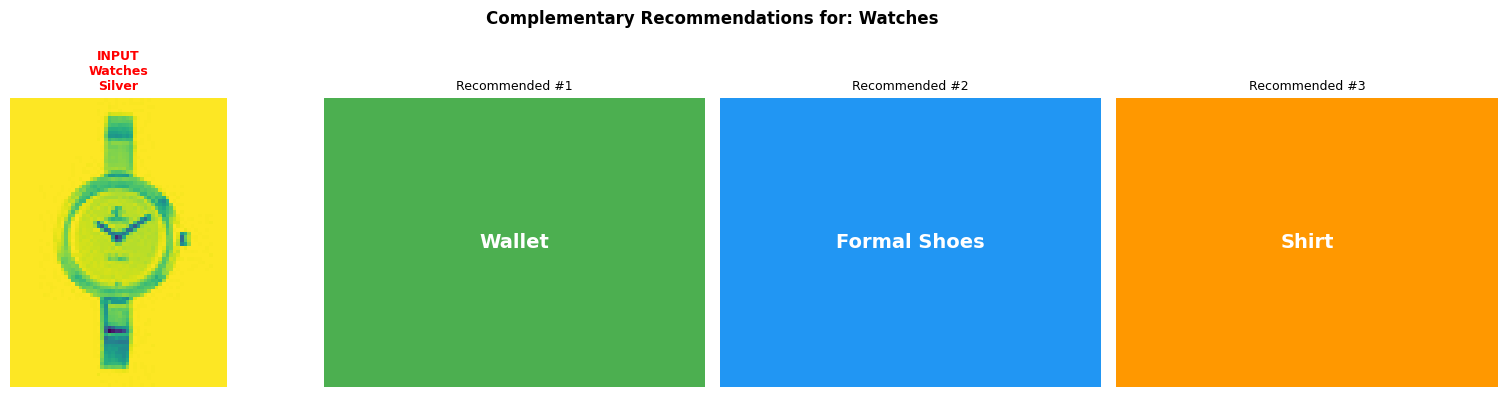

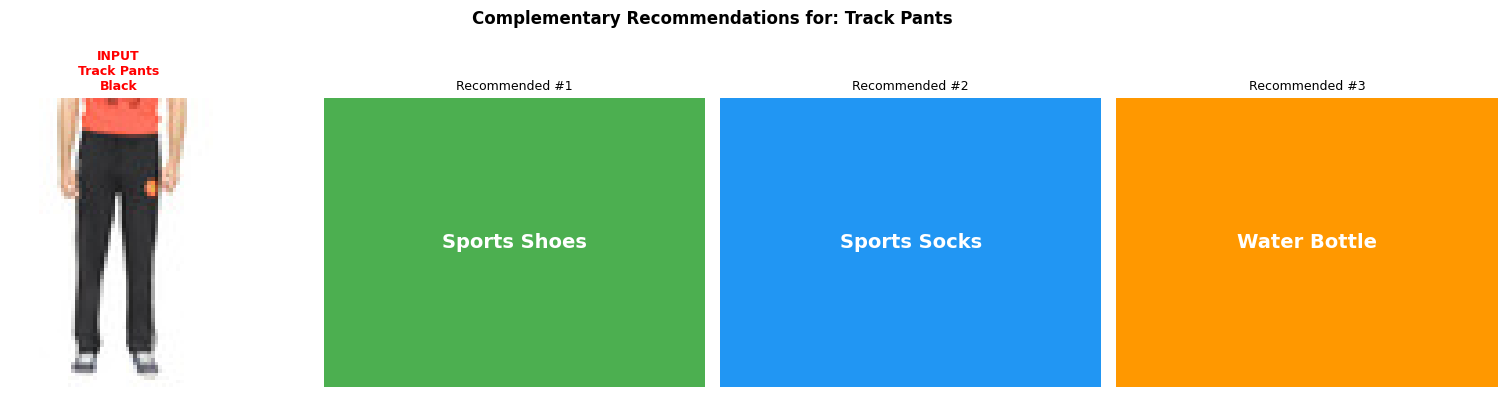

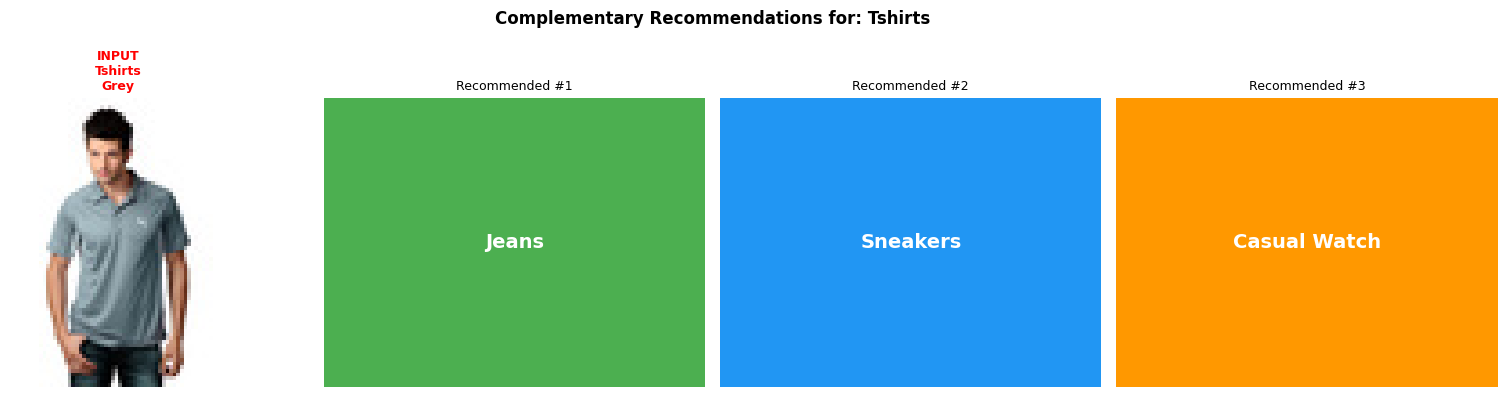

✅ Recommendations working!


In [64]:
recommendation_map = {
    "Tshirts":        ["Jeans", "Sneakers", "Casual Watch"],
    "Shirts":         ["Trousers", "Formal Shoes", "Tie"],
    "Jeans":          ["Tshirts", "Belt", "Sneakers"],
    "Dresses":        ["Heels", "Handbags", "Earrings"],
    "Track Pants":    ["Sports Shoes", "Sports Socks", "Water Bottle"],
    "Watches":        ["Wallet", "Formal Shoes", "Shirt"],
    "Casual Shoes":   ["Chinos", "Tshirts", "Sunglasses"],
    "Formal Shoes":   ["Trousers", "Shirt", "Tie"],
    "Handbags":       ["Dresses", "Heels", "Sunglasses"],
    "Tops":           ["Shorts", "Sandals", "Bracelet"],
    "Kurtas":         ["Churidar", "Sandals", "Dupatta"],
    "Sports Shoes":   ["Sports Socks", "Track Pants", "Water Bottle"],
}

def get_recommendations(query_idx):
    row = valid_df.iloc[query_idx]
    article = row["articleType"]
    recs = recommendation_map.get(article, ["Belt", "Watch", "Sunglasses"])

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.patch.set_facecolor("white")

    axes[0].imshow(Image.open(row["image_path"]))
    axes[0].set_title(f"INPUT\n{article}\n{row['baseColour']}",
                      fontsize=9, color="red", fontweight="bold")
    axes[0].axis("off")

    colors = ["#4CAF50", "#2196F3", "#FF9800"]
    for j, rec in enumerate(recs[:3]):
        axes[j+1].add_patch(plt.Rectangle((0,0), 1, 1,
                            color=colors[j], transform=axes[j+1].transAxes))
        axes[j+1].text(0.5, 0.5, rec, ha="center", va="center",
                       fontsize=14, fontweight="bold", color="white",
                       transform=axes[j+1].transAxes)
        axes[j+1].set_xlim(0,1)
        axes[j+1].set_ylim(0,1)
        axes[j+1].set_title(f"Recommended #{j+1}", fontsize=9)
        axes[j+1].axis("off")

    plt.suptitle(f"Complementary Recommendations for: {article}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

for i in [0, 1, 2, 3, 4]:
    get_recommendations(i)

print("✅ Recommendations working!")

In [66]:
print("=" * 55)
print("   AI PRODUCT INTELLIGENCE SYSTEM — SUMMARY")
print("=" * 55)
print(f"✅ Total Products Indexed    : {len(valid_df)}")
print(f"✅ Embedding Dimension       : {embeddings.shape[1]}")
print(f"✅ Model Used                : CLIP (ViT-B/32)")
print(f"✅ Similarity Metric         : Cosine Similarity")
print(f"✅ Duplicate Groups Found    : {n_clusters}")
print(f"✅ Unique Catalog Size       : {n_clusters + n_noise}")
print(f"✅ Tasks Completed           : 3 / 3")
print("=" * 55)
print("\nTasks:")
print("  Task 1 ✅ Smart Recommendation Engine")
print("  Task 2 ✅ Unique Product Catalog (Duplicate Detection)")
print("  Task 3 ✅ Reverse Text Search")
print("=" * 55)

   AI PRODUCT INTELLIGENCE SYSTEM — SUMMARY
✅ Total Products Indexed    : 500
✅ Embedding Dimension       : 512
✅ Model Used                : CLIP (ViT-B/32)
✅ Similarity Metric         : Cosine Similarity
✅ Duplicate Groups Found    : 16
✅ Unique Catalog Size       : 84
✅ Tasks Completed           : 3 / 3

Tasks:
  Task 1 ✅ Smart Recommendation Engine
  Task 2 ✅ Unique Product Catalog (Duplicate Detection)
  Task 3 ✅ Reverse Text Search
